In [2]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error

In [3]:
df = pd.read_csv('csv/fitness_dataset.csv')

#### Tirando todos os valores vazios:

In [4]:
df.dropna(inplace = True)

#### Trocando a coluna para o machine learning:

In [57]:
df['smokes'] = df['smokes'].replace({'yes': 1, 'no': 0})

In [58]:
df['smokes'] = df['smokes'].apply(lambda x : int(x))

#### Fazendo copia do df:


In [59]:
machine_df = df.copy()

#### Add coluna para o machine learning:

In [60]:
machine_df['gender_m'] = machine_df['gender'].apply(lambda x : 1 if x == 'M' else 0)
machine_df['gender_f'] = machine_df['gender'].apply(lambda x : 1 if x == 'F' else 0)

# Quantidade de pessoas pela idade:

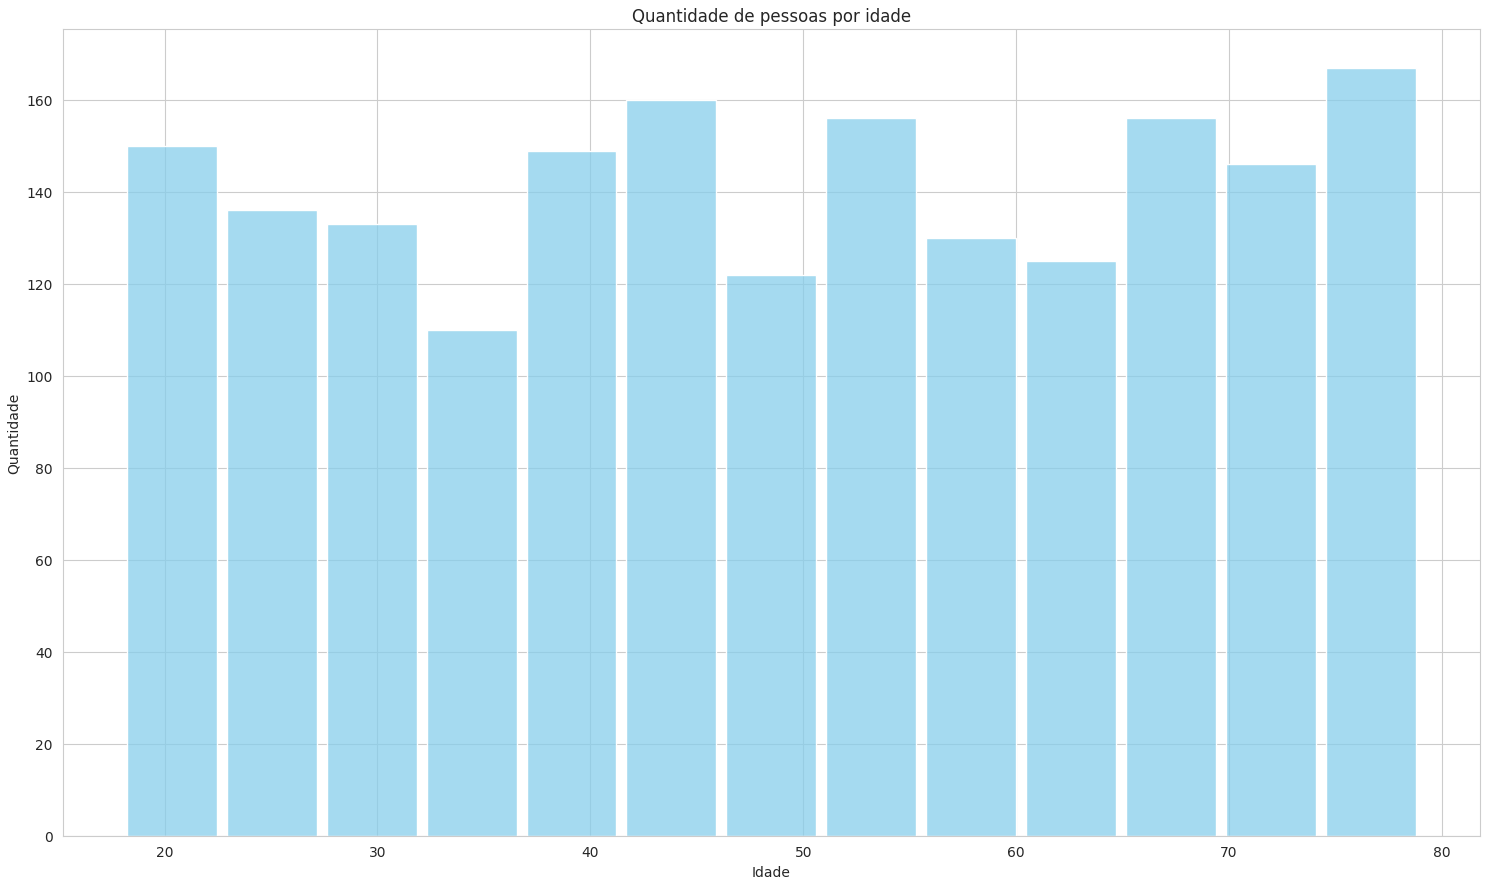

In [61]:
with sns.axes_style('whitegrid'):
    plt.figure(figsize = (15,9))
    grafico = sns.histplot(data = df, x = 'age',shrink = 0.9, color = 'skyblue')
    grafico.set(title = 'Quantidade de pessoas por idade', xlabel = 'Idade', ylabel = 'Quantidade')
    plt.tight_layout()

# Peso pela idade:

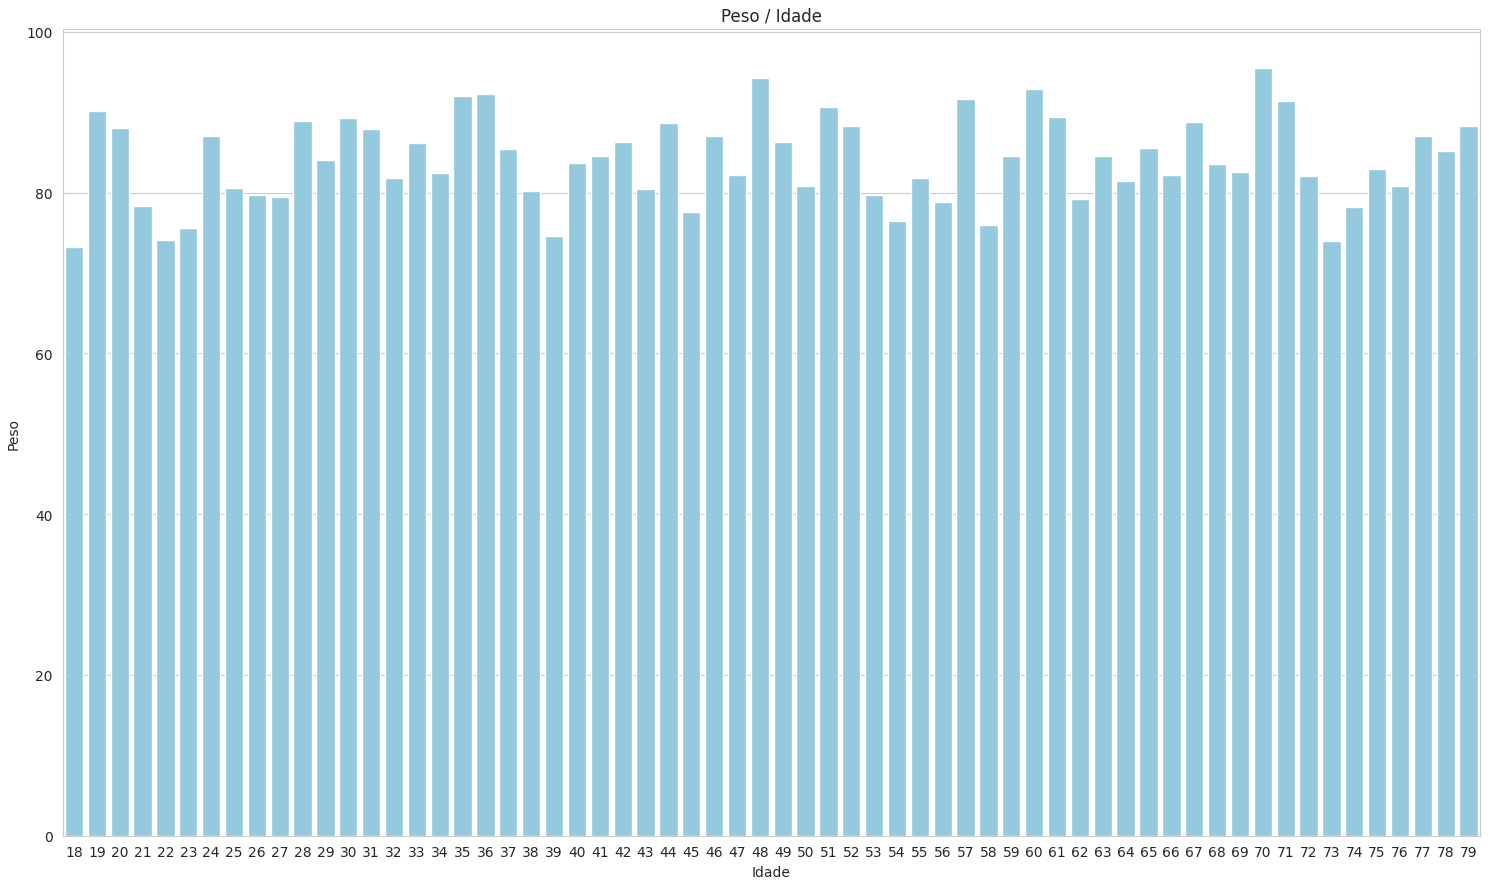

In [62]:
ano_peso = df[['age','weight_kg']].groupby('age').mean().round(2).reset_index()
with sns.axes_style('whitegrid'):
    plt.figure(figsize = (15,9))
    grafico = sns.barplot(data = ano_peso, x = 'age', y = 'weight_kg', color = 'skyblue')
    grafico.set(title = 'Peso / Idade',xlabel = 'Idade', ylabel = 'Peso')
    plt.tight_layout()

# Peso em relacao ao frequencia cardiaca:

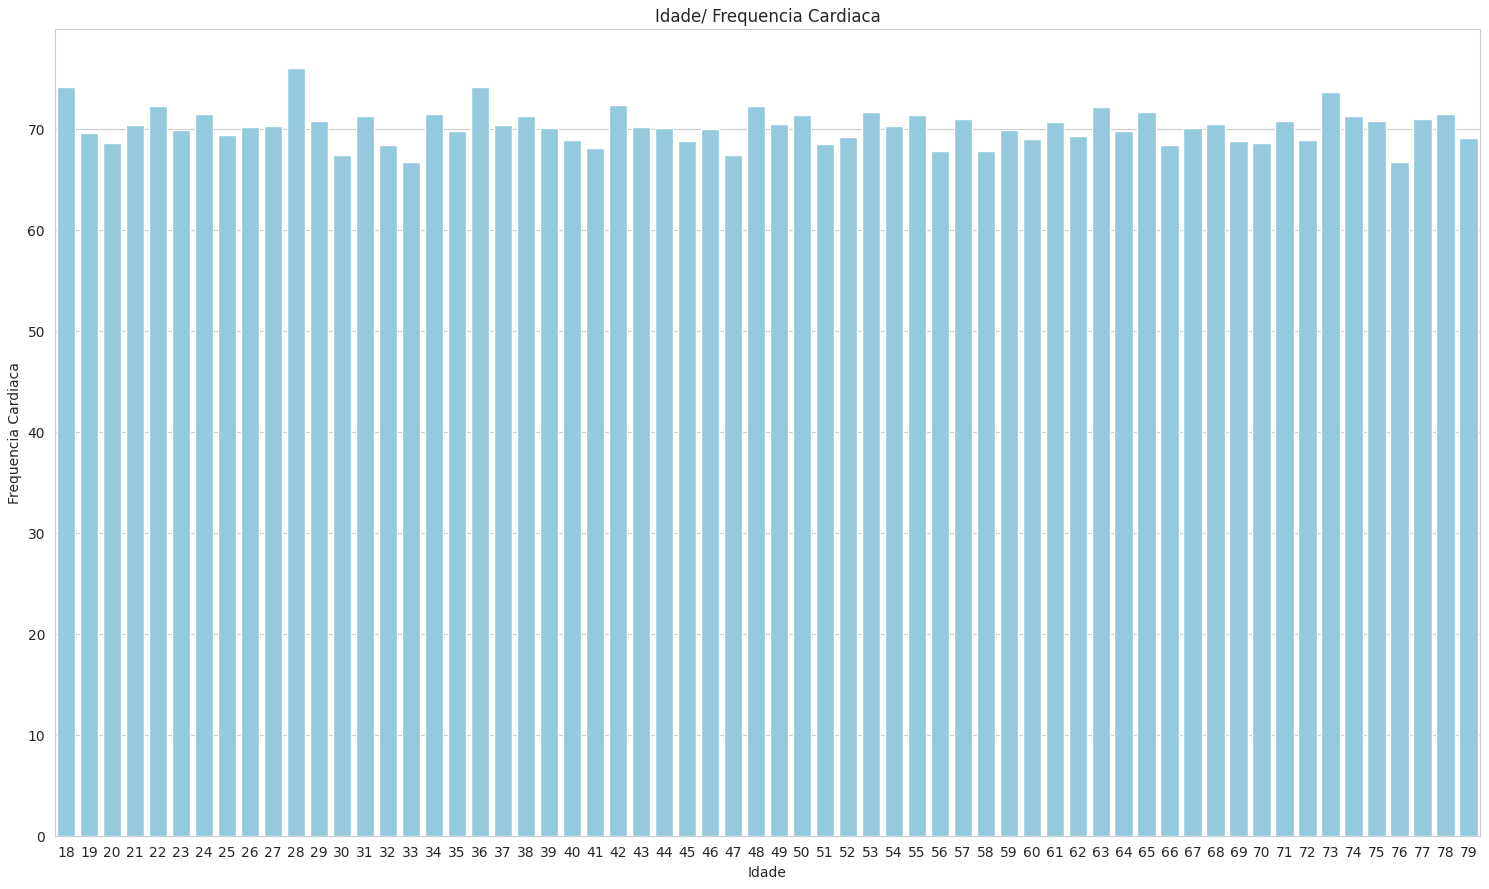

In [63]:
ano_heart = df[['age','heart_rate']].groupby('age').mean().round(2).reset_index()
ano_heart
with sns.axes_style('whitegrid'):
    plt.figure(figsize=(15,9))
    grafico = sns.barplot(data = ano_heart , x = 'age',y = 'heart_rate', color = 'skyblue')
    grafico.set(title =  'Idade/ Frequencia Cardiaca', xlabel = 'Idade', ylabel = 'Frequencia Cardiaca')
    plt.tight_layout()

# Idade media pela pressao:

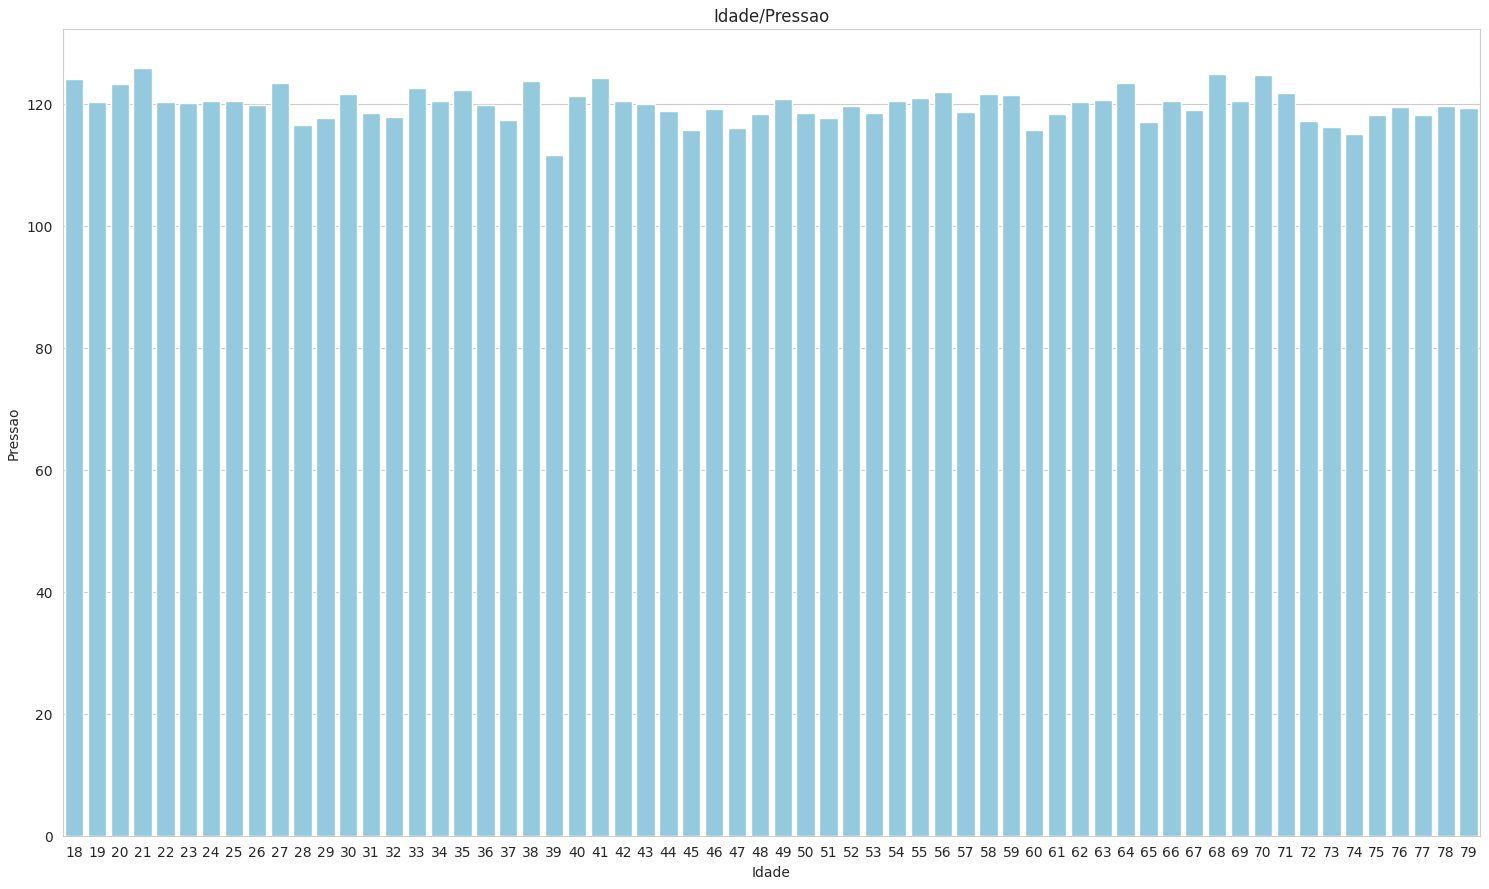

In [64]:
ano_pressao = df[['age','blood_pressure']].groupby('age').mean().round(2).reset_index()

with sns.axes_style('whitegrid'):
    plt.figure(figsize=(15,9))
    grafico = sns.barplot(data = ano_pressao, x = 'age',y = 'blood_pressure', color = 'skyblue')
    grafico.set(title = 'Idade/Pressao', xlabel = 'Idade',ylabel = 'Pressao')
    plt.tight_layout()

# Idade por horas:

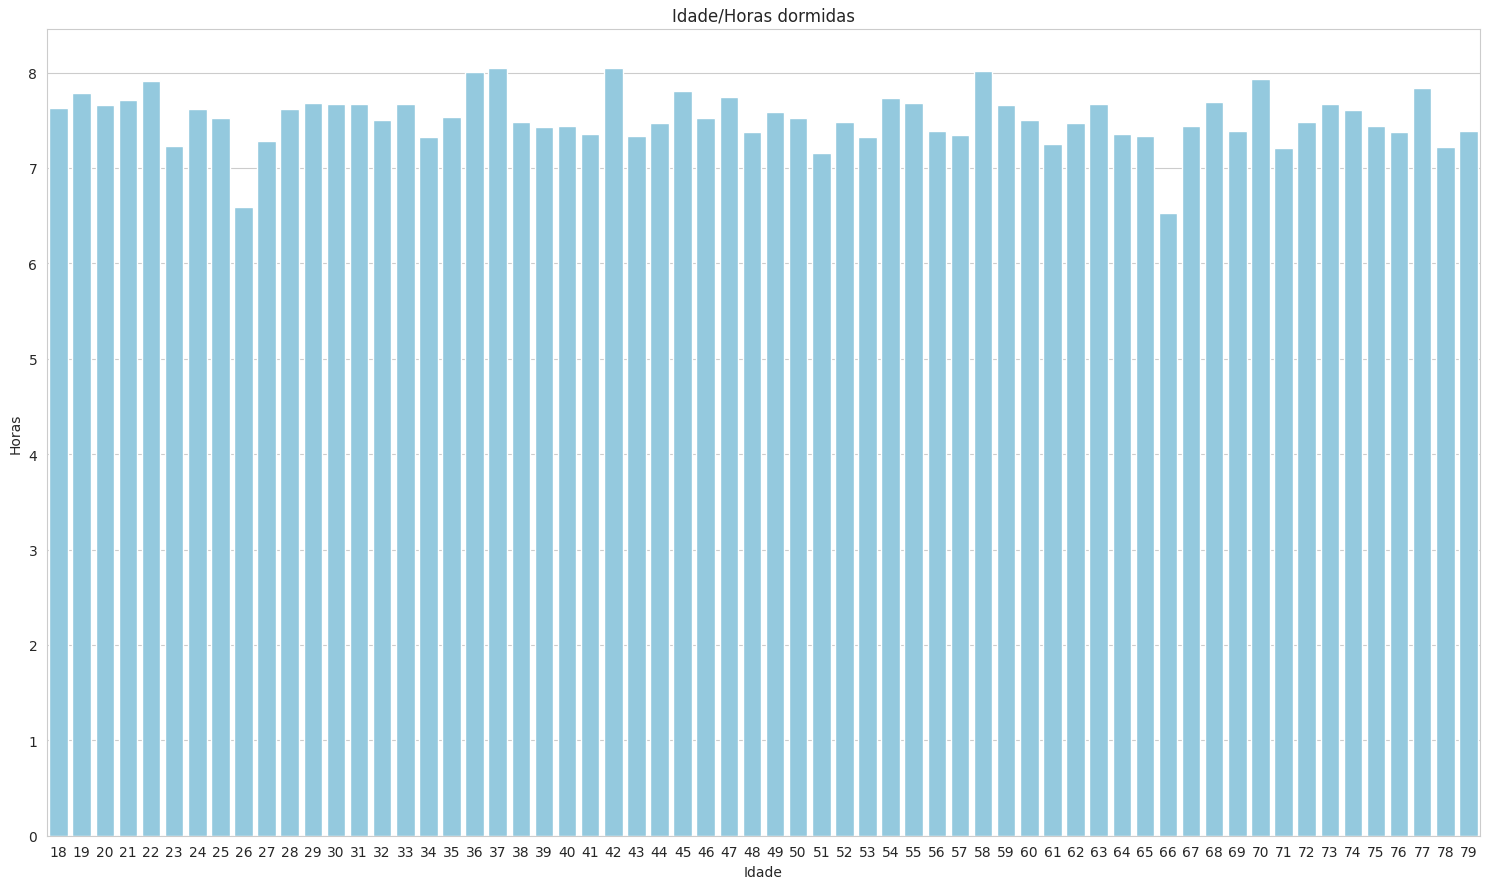

In [65]:
idade_h_dormidas = df[['age','sleep_hours']].groupby('age').mean().round(2).reset_index()
with sns.axes_style('whitegrid'):
    plt.figure(figsize=(15,9))
    grafico = sns.barplot(data = idade_h_dormidas, x = 'age',y = 'sleep_hours', color = 'skyblue')
    grafico.set(title = 'Idade/Horas dormidas', xlabel = 'Idade',ylabel = 'Horas')
    plt.tight_layout()

# Idade por qualidade de nutricao:

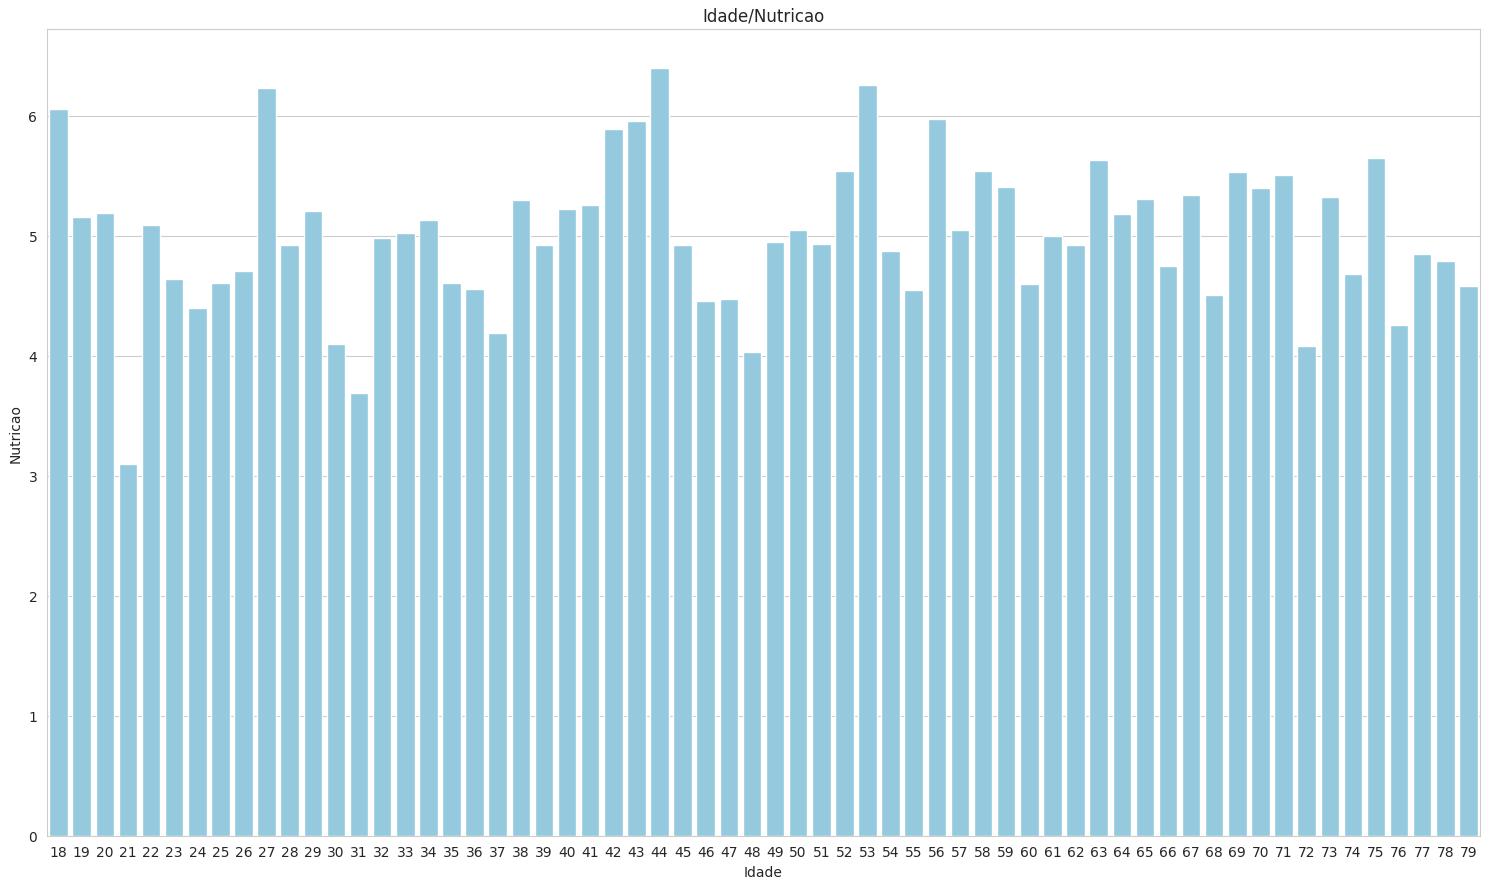

In [66]:
idade_nutricao = df[['age','nutrition_quality']].groupby('age').mean().round(2).reset_index()
with sns.axes_style('whitegrid'):
    plt.figure(figsize=(15,9))
    grafico = sns.barplot(data = idade_nutricao, x = 'age',y = 'nutrition_quality', color = 'skyblue')
    grafico.set(title = 'Idade/Nutricao', xlabel = 'Idade',ylabel = 'Nutricao')
    plt.tight_layout()

# Idade por tempo de atividades

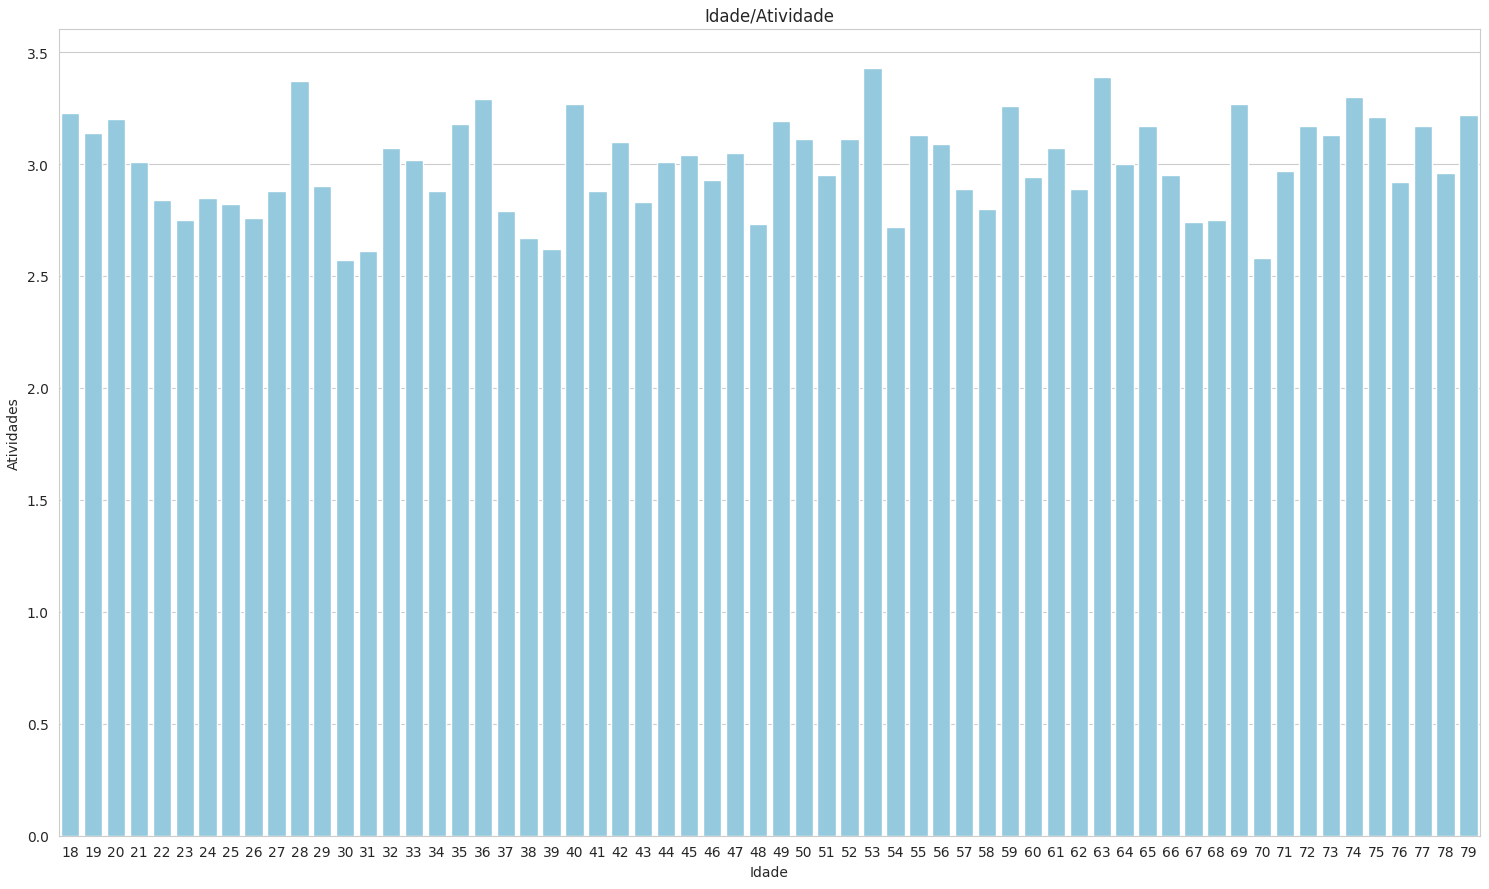

In [67]:
idade_atividade = df[['age','activity_index']].groupby('age').mean().round(2).reset_index()
with sns.axes_style('whitegrid'):
    plt.figure(figsize=(15,9))
    grafico = sns.barplot(data = idade_atividade, x = 'age',y = 'activity_index', color = 'skyblue')
    grafico.set(title = 'Idade/Atividade', xlabel = 'Idade',ylabel = 'Atividades')
    plt.tight_layout()

# Idade/fumantes:

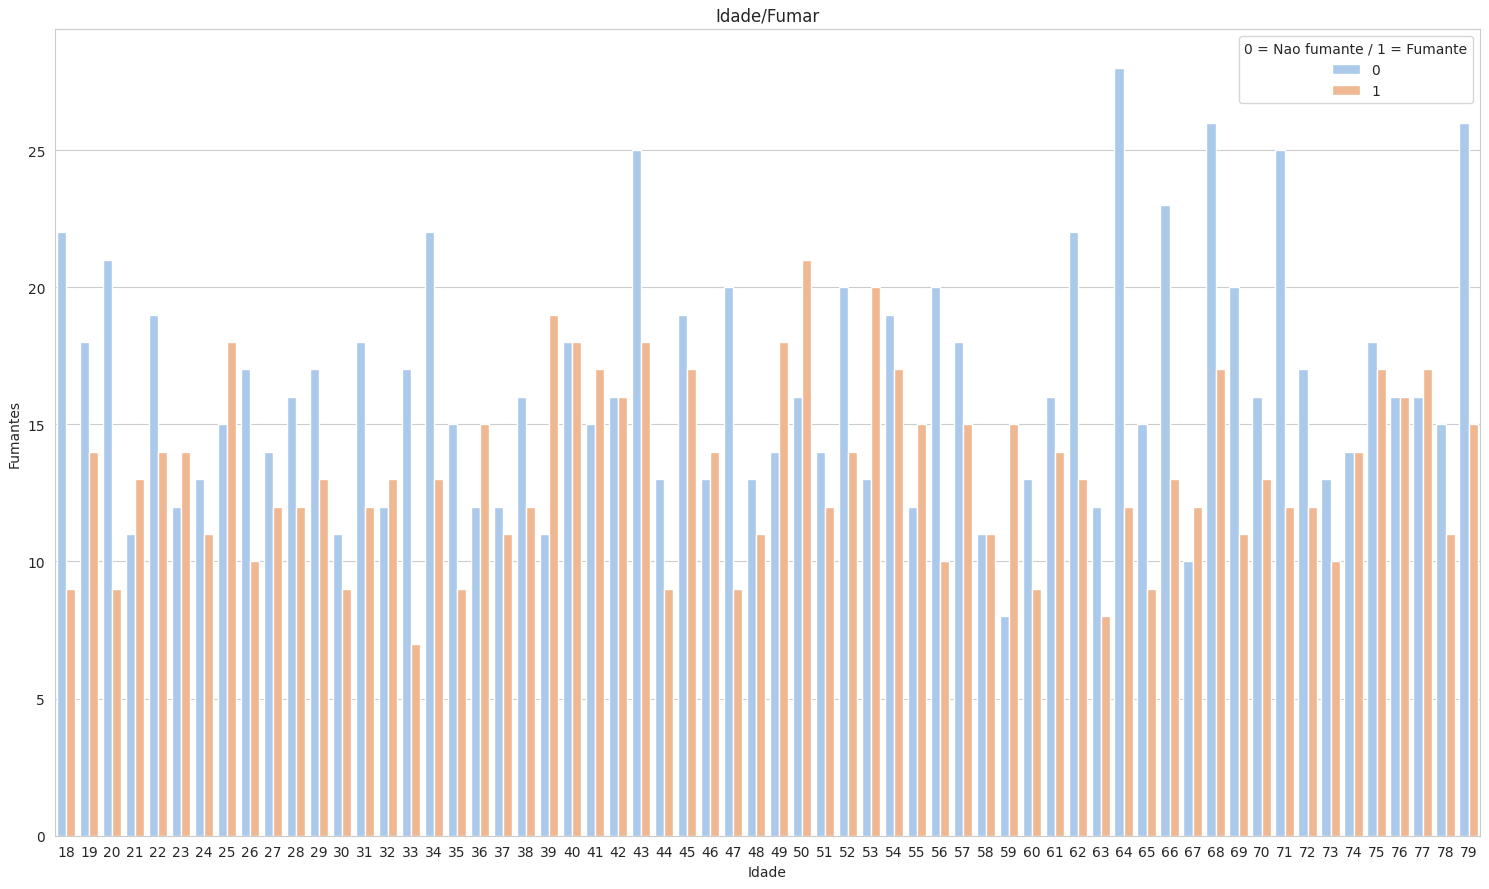

In [68]:
idade_fumar = df[['age','smokes']].groupby('age').value_counts().reset_index()
with sns.axes_style('whitegrid'):
    plt.figure(figsize=(15,9))
    grafico = sns.barplot(data = idade_fumar, x = 'age', y = 'count', hue = 'smokes', palette= 'pastel') 
    grafico.set(title = 'Idade/Fumar', xlabel = 'Idade',ylabel = 'Fumantes')
    plt.legend(title = '0 = Nao fumante / 1 = Fumante')
    plt.tight_layout()

# Idade/fits:

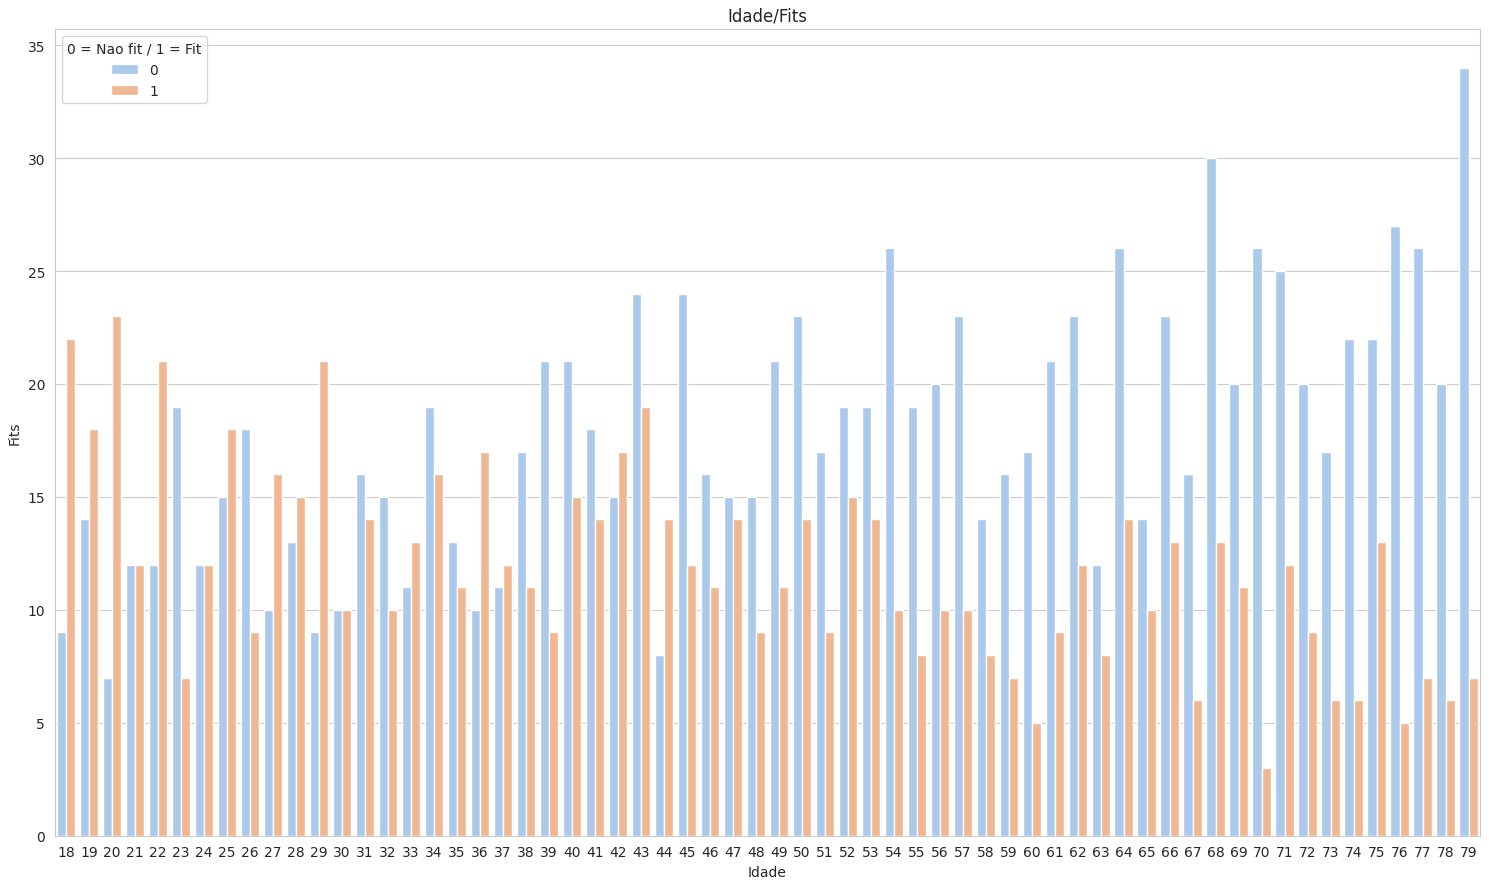

In [69]:
idade_fit = df[['age','is_fit']].groupby('age').value_counts().reset_index()
with sns.axes_style('whitegrid'):
    plt.figure(figsize=(15,9))
    grafico = sns.barplot(data = idade_fit, x = 'age', y = 'count', hue = 'is_fit', palette= 'pastel') 
    grafico.set(title = 'Idade/Fits', xlabel = 'Idade',ylabel = 'Fits')
    plt.legend(title = '0 = Nao fit / 1 = Fit')
    plt.tight_layout()

# Pessoas por altura:

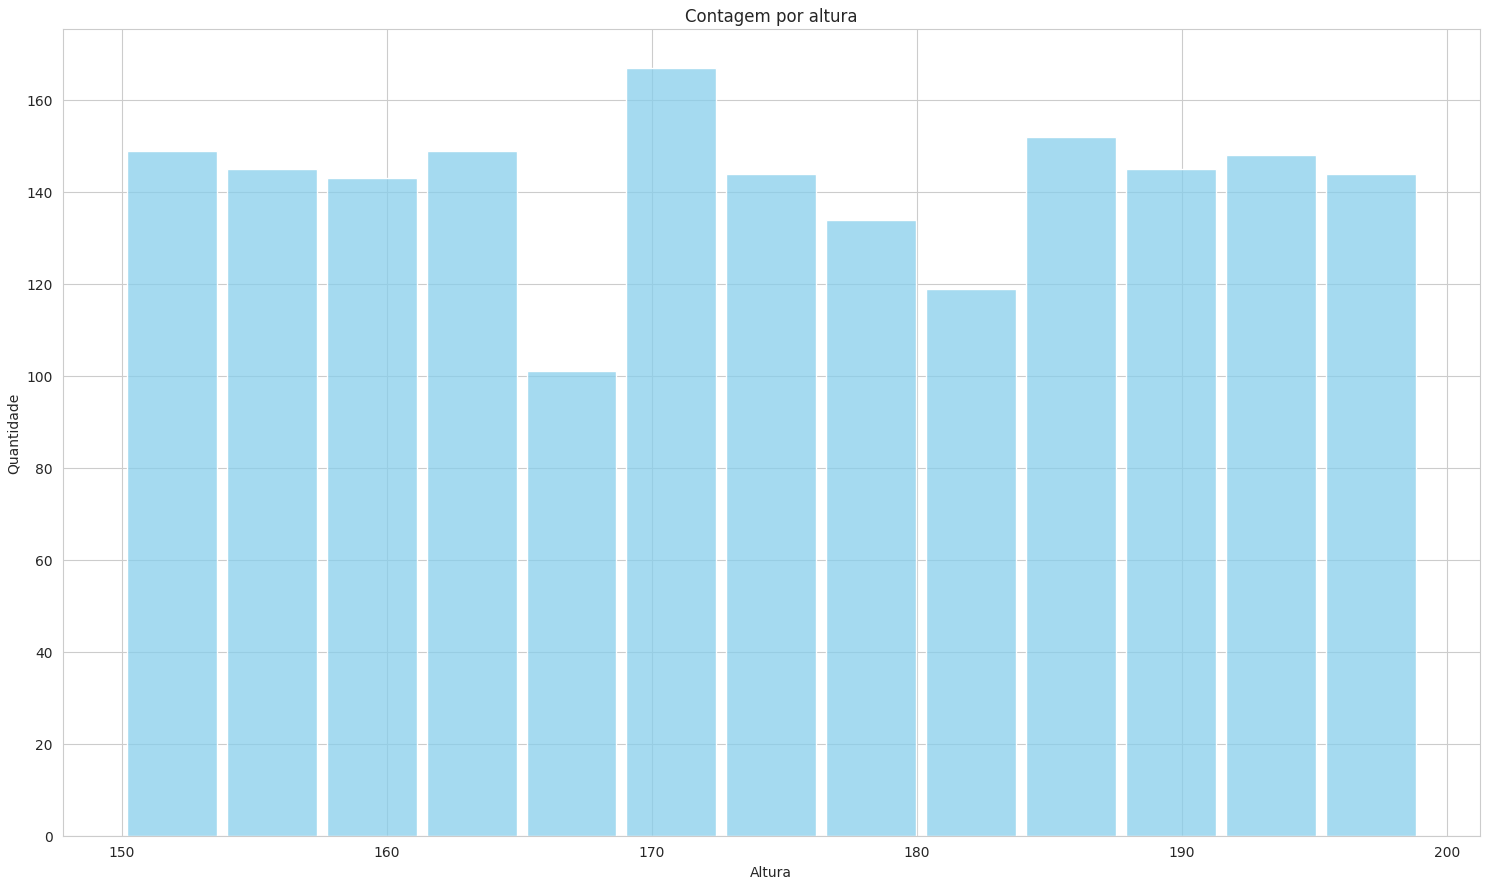

In [70]:
with sns.axes_style('whitegrid'):
    plt.figure(figsize=(15,9))
    grafico = sns.histplot(data= df, x = 'height_cm', color = 'skyblue',shrink = 0.9)
    grafico.set(title = 'Contagem por altura', xlabel = 'Altura', ylabel = 'Quantidade')
    plt.tight_layout()


# Quantidade de pessoas por peso:

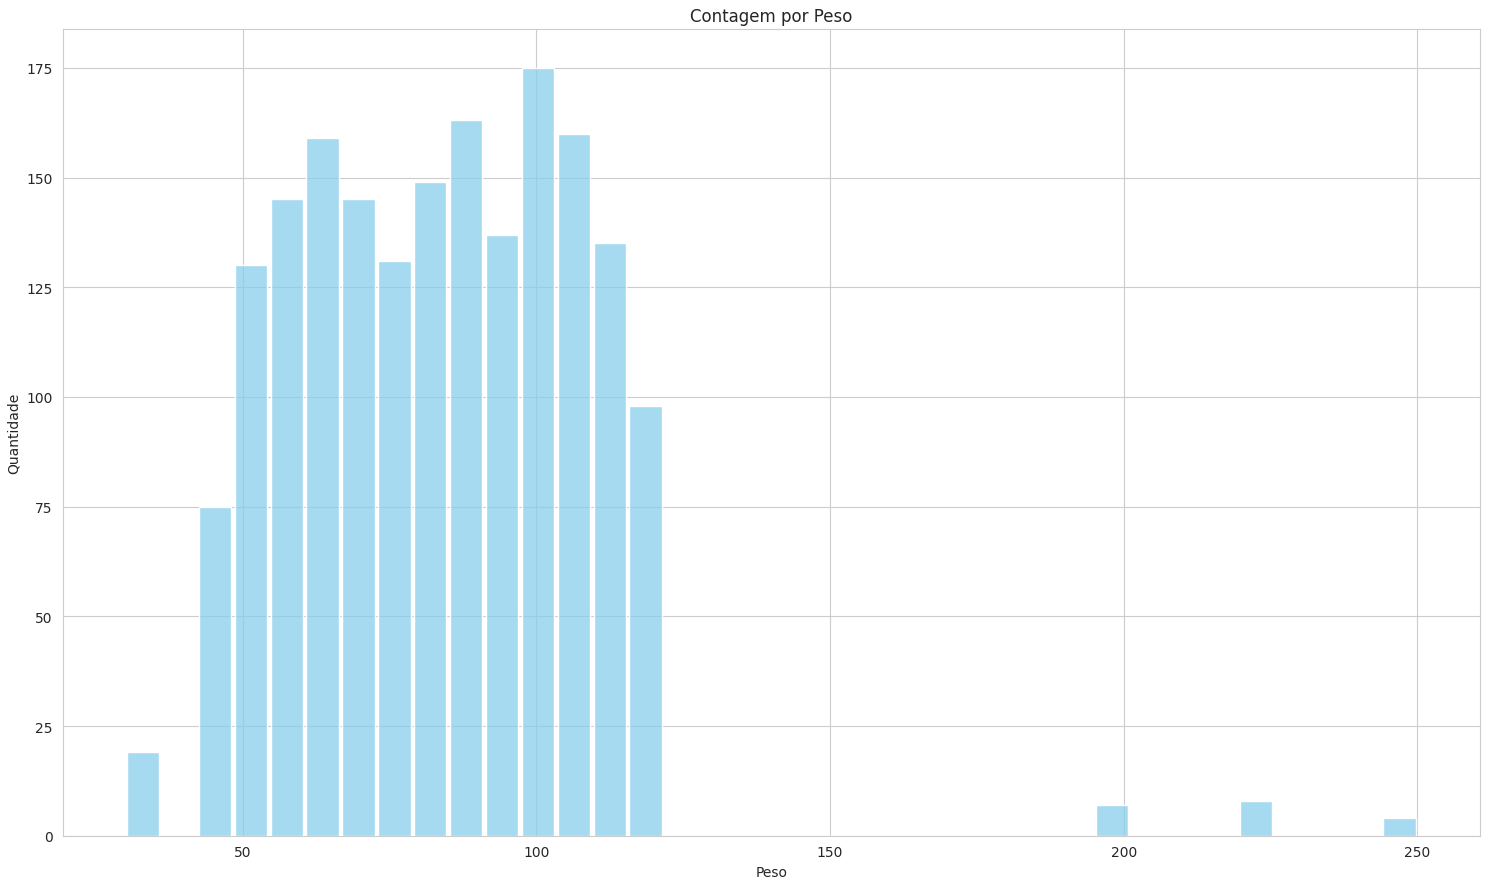

In [71]:
with sns.axes_style('whitegrid'):
    plt.figure(figsize=(15,9))
    grafico = sns.histplot(data= df, x = 'weight_kg', color = 'skyblue',shrink = 0.9)
    grafico.set(title = 'Contagem por Peso', xlabel = 'Peso', ylabel = 'Quantidade')
    plt.tight_layout()

# Peso / Batimentos: 

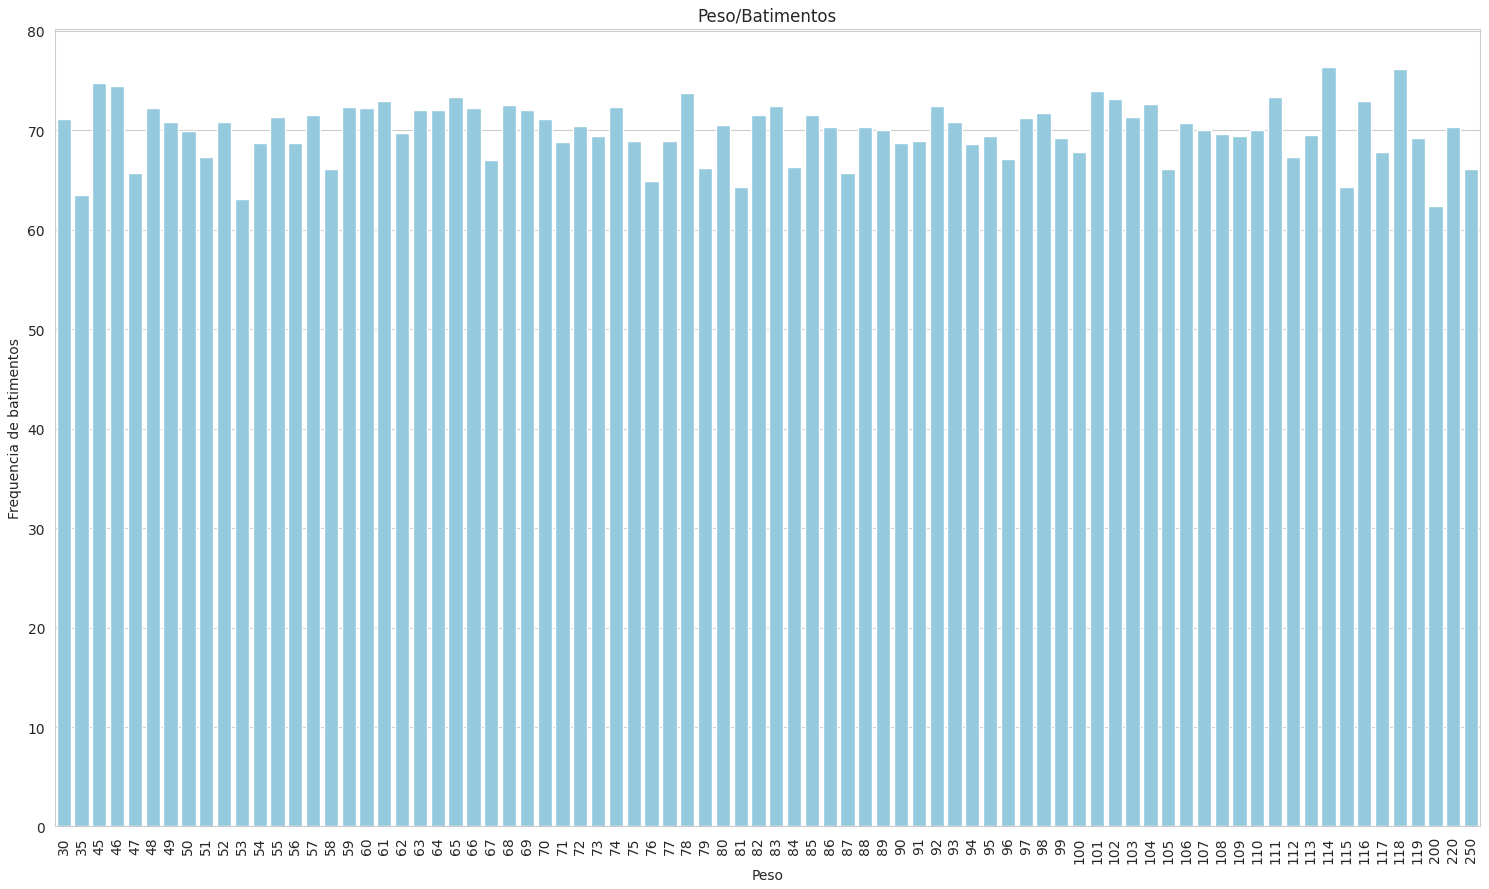

In [72]:
batimentos_por_peso = df[['weight_kg','heart_rate']].groupby('weight_kg').mean().round(2).reset_index()
with sns.axes_style('whitegrid'):
    plt.figure(figsize=(15,9))
    grafico = sns.barplot(data = batimentos_por_peso , x = 'weight_kg', y = 'heart_rate', color = 'skyblue')
    grafico.set(title = 'Peso/Batimentos', xlabel = 'Peso', ylabel = 'Frequencia de batimentos')
    plt.xticks(rotation = 90)
    plt.tight_layout()

# Peso / Pressao sanguinia:

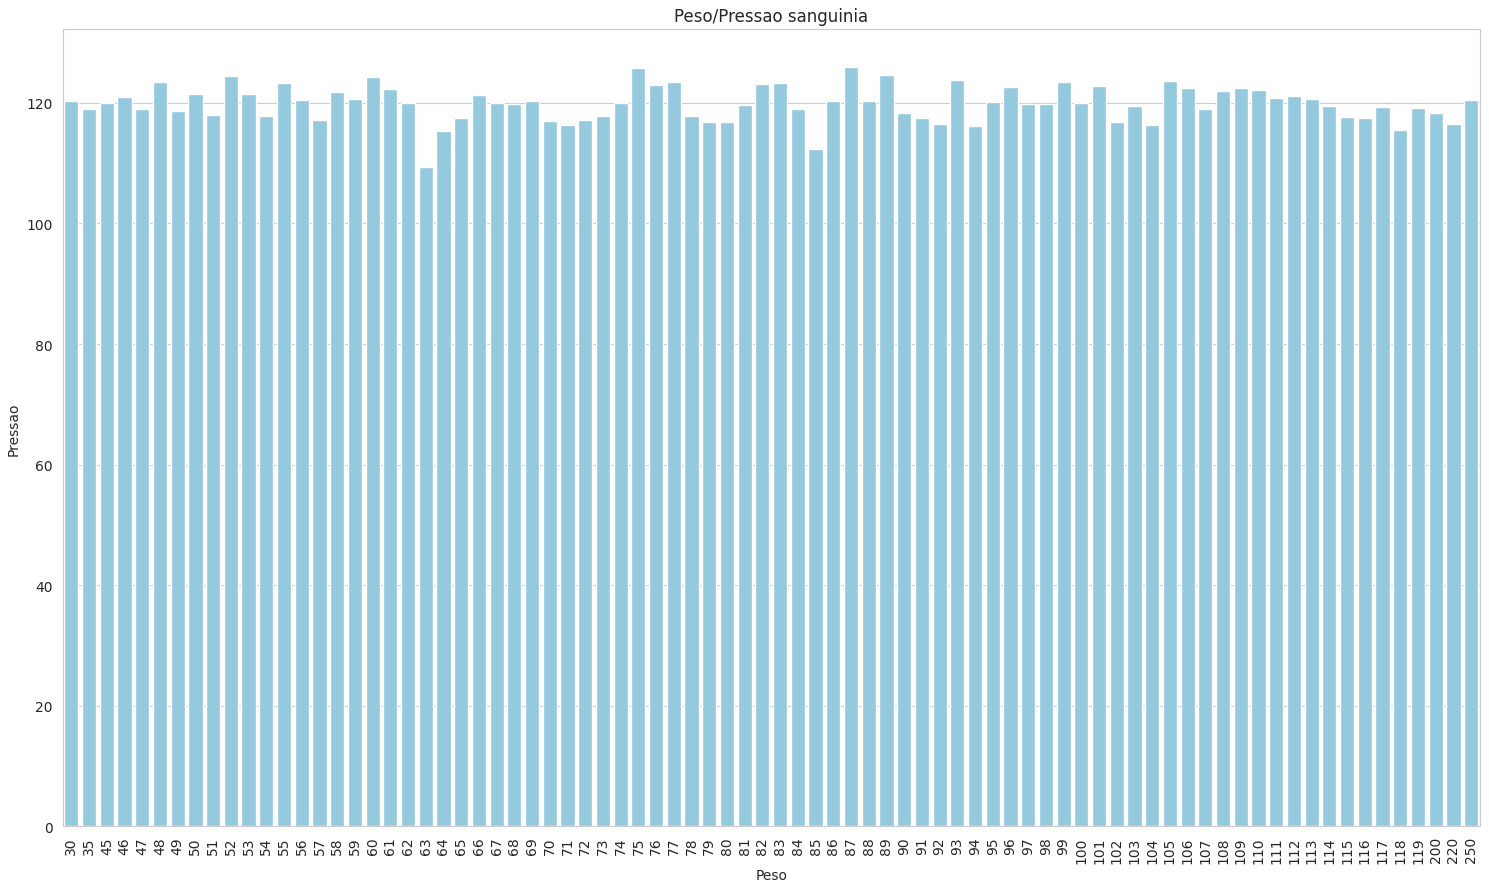

In [73]:
pressao_por_peso = df[['weight_kg','blood_pressure']].groupby('weight_kg').mean().round(2).reset_index()
with sns.axes_style('whitegrid'):
    plt.figure(figsize=(15,9))
    grafico = sns.barplot(data = pressao_por_peso , x = 'weight_kg', y = 'blood_pressure', color = 'skyblue')
    grafico.set(title = 'Peso/Pressao sanguinia', xlabel = 'Peso', ylabel = 'Pressao')
    plt.xticks(rotation = 90)
    plt.tight_layout()

# Peso / nutricao:

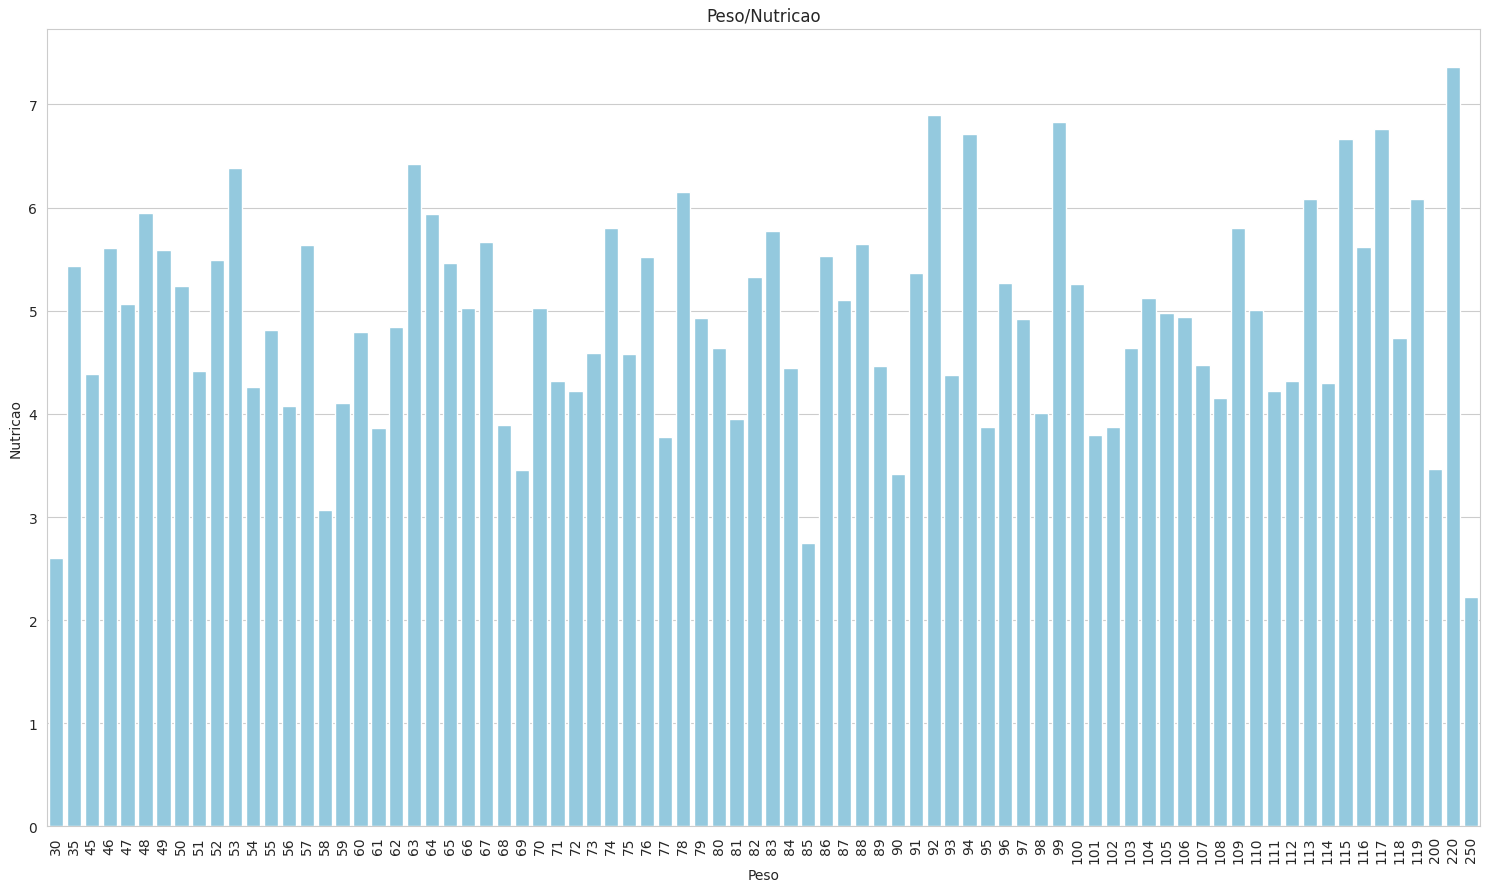

In [74]:
nutricao_por_peso = df[['weight_kg','nutrition_quality']].groupby('weight_kg').median().round(2).reset_index()
with sns.axes_style('whitegrid'):
    plt.figure(figsize=(15,9))
    grafico = sns.barplot(data = nutricao_por_peso, x = 'weight_kg', y = 'nutrition_quality', color = 'skyblue')
    grafico.set(title = 'Peso/Nutricao', xlabel = 'Peso', ylabel = 'Nutricao')
    plt.xticks(rotation = 90)
    plt.tight_layout()

# Peso / Atividade:

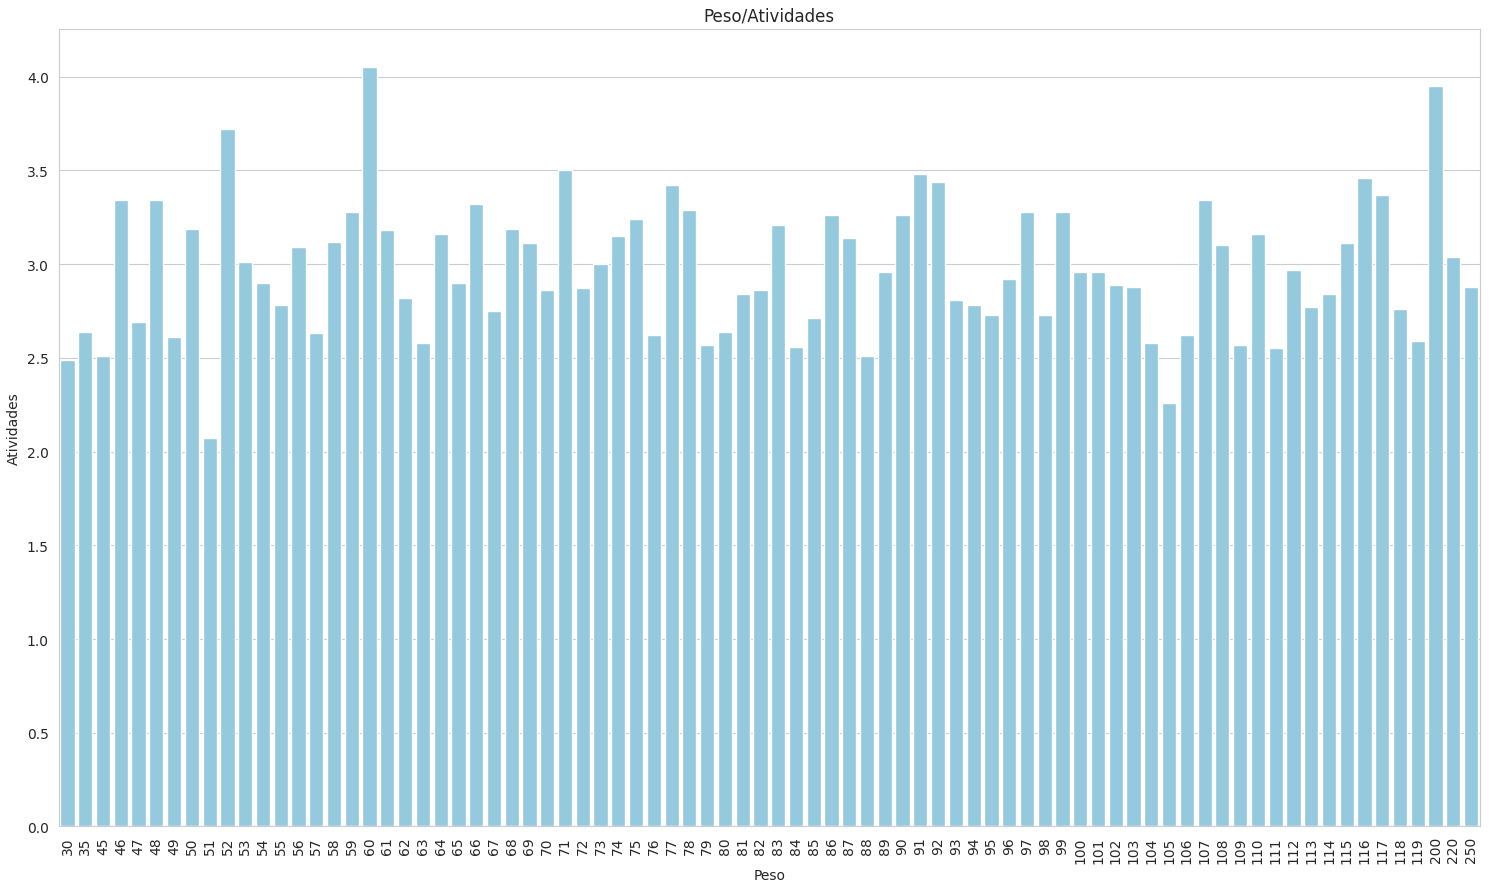

In [75]:
nutricao_por_peso = df[['weight_kg','activity_index']].groupby('weight_kg').median().round(2).reset_index()
with sns.axes_style('whitegrid'):
    plt.figure(figsize=(15,9))
    grafico = sns.barplot(data = nutricao_por_peso, x = 'weight_kg', y = 'activity_index', color = 'skyblue')
    grafico.set(title = 'Peso/Atividades', xlabel = 'Peso', ylabel = 'Atividades')
    plt.xticks(rotation = 90)
    plt.tight_layout()

# Peso / Fumantes:

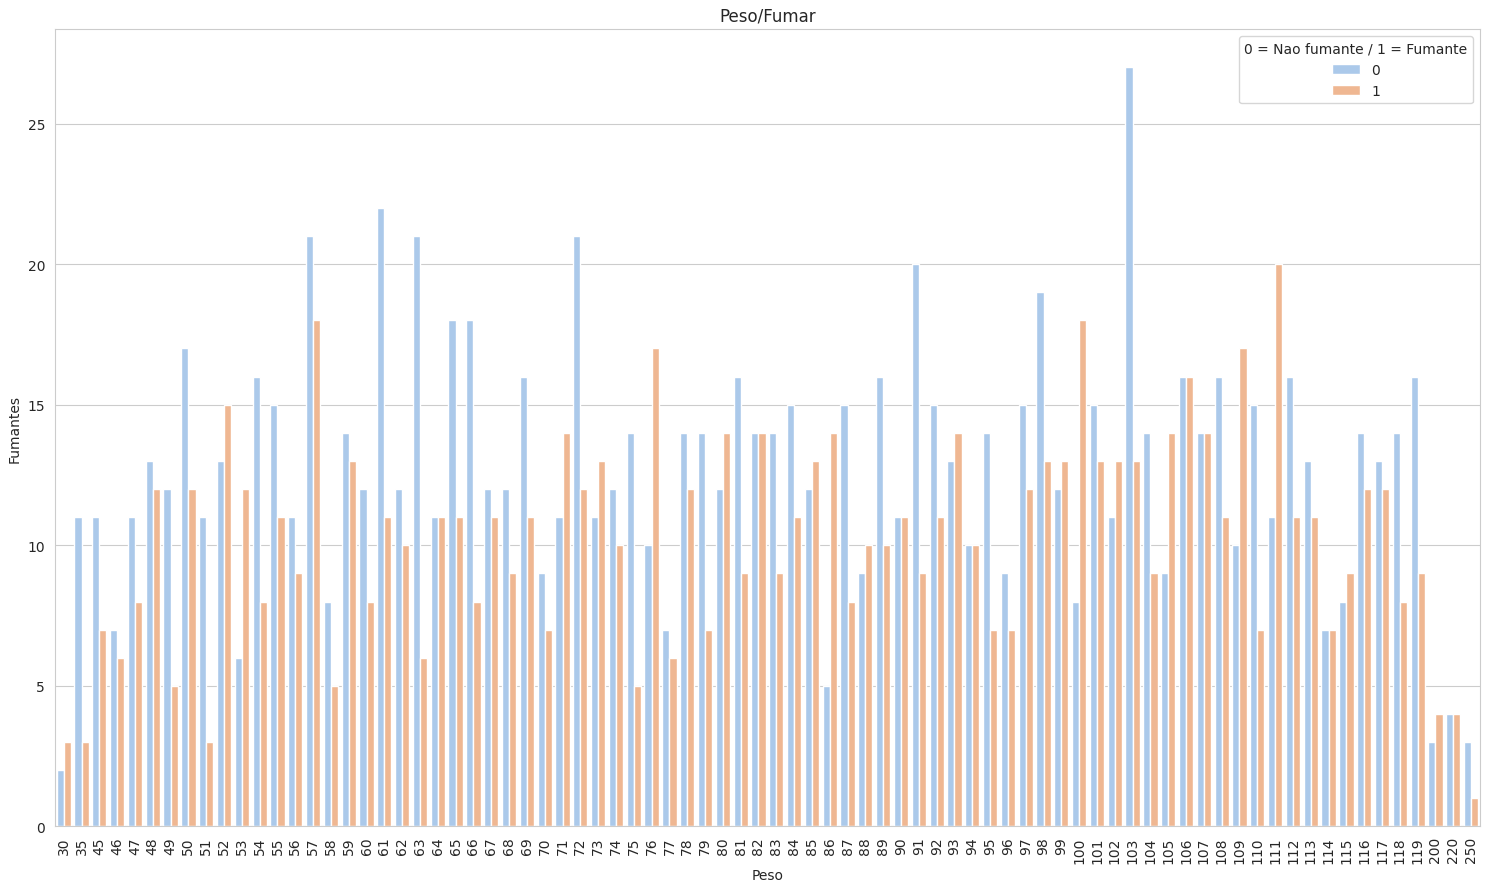

In [76]:
peso_fumar = df[['weight_kg','smokes']].groupby('weight_kg').value_counts().reset_index()
with sns.axes_style('whitegrid'):
    plt.figure(figsize=(15,9))
    grafico = sns.barplot(data = peso_fumar, x = 'weight_kg', y = 'count', hue = 'smokes', palette= 'pastel') 
    grafico.set(title = 'Peso/Fumar', xlabel = 'Peso',ylabel = 'Fumantes')
    plt.legend(title = '0 = Nao fumante / 1 = Fumante')
    plt.xticks(rotation = (90))
    plt.tight_layout()

# Peso / Fits:

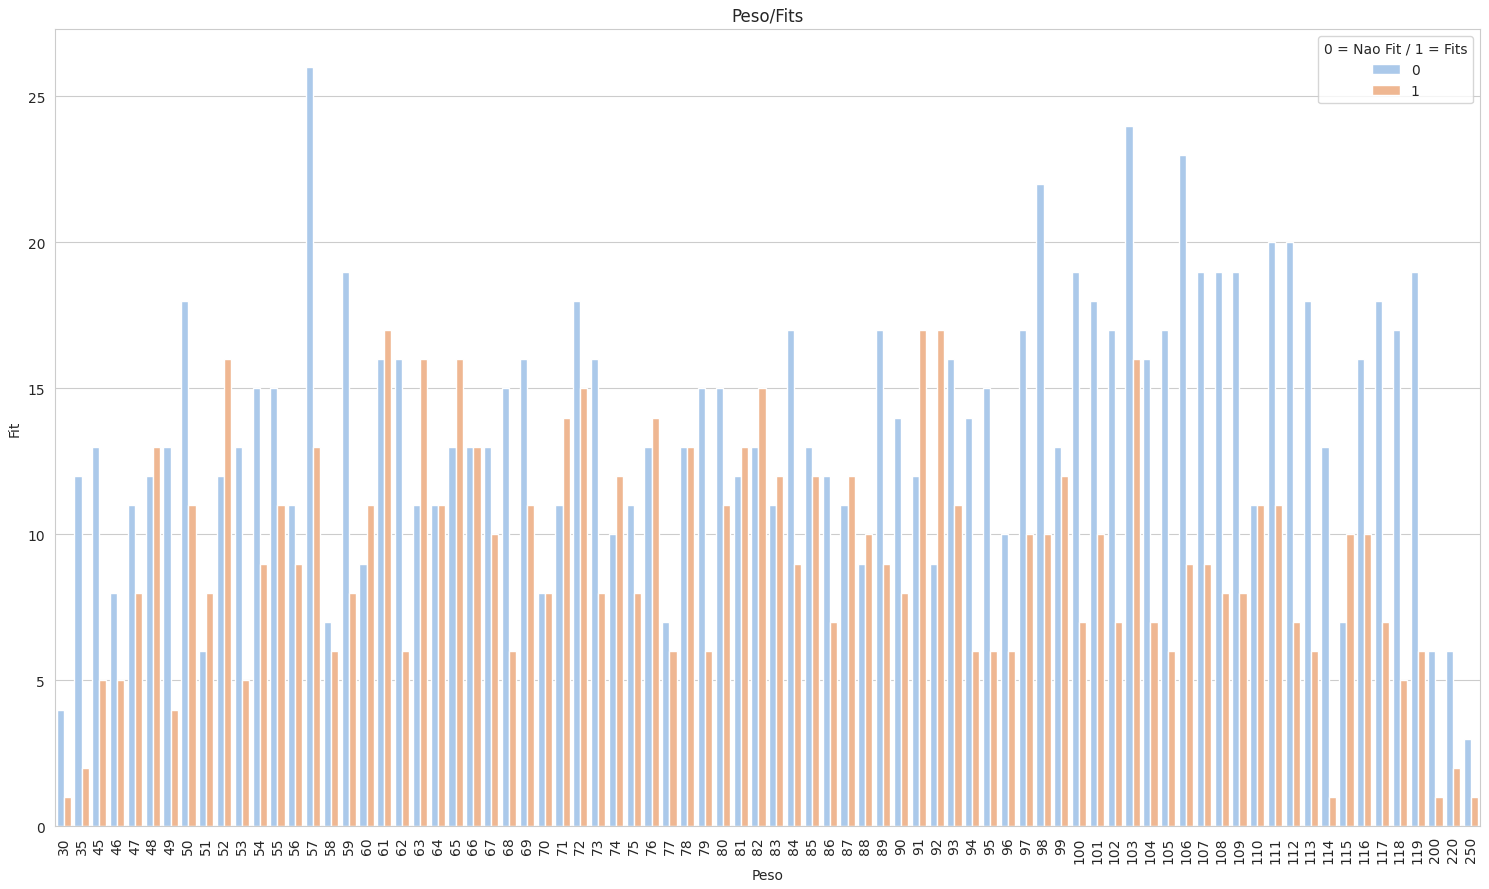

In [77]:
peso_fumar = df[['weight_kg','is_fit']].groupby('weight_kg').value_counts().reset_index()
with sns.axes_style('whitegrid'):
    plt.figure(figsize=(15,9))
    grafico = sns.barplot(data = peso_fumar, x = 'weight_kg', y = 'count', hue = 'is_fit', palette= 'pastel') 
    grafico.set(title = 'Peso/Fits', xlabel = 'Peso',ylabel = 'Fit')
    plt.legend(title = '0 = Nao Fit / 1 = Fits')
    plt.xticks(rotation = (90))
    plt.tight_layout()

# Correlaçoes:

In [78]:
correlacao = np.corrcoef(df['age'], df['weight_kg'])[0,1]
print(f'A correlação é de {correlacao * 100:.2f}%')

A correlação é de 2.77%


## Correlação altura com peso:

- muito baixa quase inexistente

- 0.65% das vezes quando a altura aumenta o peso tambem aumenta

In [79]:
correlacao = np.corrcoef(df['height_cm'],df['weight_kg'])[0,1]
print(f'A correlação é de {correlacao * 100:.2f}%')

A correlação é de 0.65%


## Correlação frequencia cardiaca com peso:

- Correlação levemente negativa logo quando uma sobe a outra dece

- -1.15% das vezes quando a frequencia sobe o peso dece (ou vice-versa)

In [80]:
correlacao = np.corrcoef(df['heart_rate'],df['weight_kg'])[0,1]
print(f'A correlação é de {correlacao * 100:.2f}%')

A correlação é de -1.15%


## Correlação pressao sanguinia com peso:

- Correlação levemente negativa logo quando uma sobe a outra dece

- -1.15% das vezes quando a pressao sobe o peso dece (ou vice-versa)

In [81]:
correlacao = np.corrcoef(df['blood_pressure'],df['weight_kg'])[0,1] 
print(f'A correlação é de {correlacao * 100:.2f}%')

A correlação é de -0.53%


## Correlação idade com peso:

- correlação levemente positiva

- 2,7% das vezes quando a idade aumenta o peso tambem aumenta  

## Correlação horas dormidas com peso:

- muito baixa quase inexistente

- 0.66% das vezes quando a horas dormidas aumentam o peso tambem aumenta

In [82]:
correlacao = np.corrcoef(df['sleep_hours'],df['weight_kg'])[0,1]
print(f'A correlação é de {correlacao * 100:.2f}%')

A correlação é de 0.66%


## Correlação qualidade de nutricao com peso:

- Praticamente inexistente 

In [83]:
correlacao = np.corrcoef(df['nutrition_quality'],df['weight_kg'])[0,1]
print(f'A correlação é de {correlacao * 100:.2f}%')

A correlação é de -0.12%


## Correlação qualidade de atividades com peso:

- Correlação negativa logo quando um sobe outro dece

- 2.38% das vezes que as atividades aumentam o peso diminui (ou vice-versa)

In [84]:
correlacao = np.corrcoef(df['activity_index'],df['weight_kg'])[0,1]
print(f'A correlação é de {correlacao * 100:.2f}%')

A correlação é de -2.38%


## Correlação de fumantes com peso:

- Correlação positiva 

- 3.69% das vezes quando a pessoa fuma ela aumenta de peso

In [85]:
correlacao = np.corrcoef(df['smokes'],df['weight_kg'])[0,1]
print(f'A correlação é de {correlacao * 100:.2f}%')

A correlação é de 3.69%


## Correlação de fitnes com peso:

- Correlação negativa

- 7.94% das vezes que a pessoa e fitnes ela o peso dela abaixa (vice-versa)

In [86]:
correlacao = np.corrcoef(df['is_fit'],df['weight_kg'])[0,1]
print(f'A correlação é de {correlacao * 100:.2f}%')

A correlação é de -7.94%


# Preparacao para o machine learn:

In [87]:
df

,age,height_cm,weight_kg,heart_rate,blood_pressure,sleep_hours,nutrition_quality,activity_index,smokes,gender,is_fit
1,69,186,95,60.8,114.8,7.5,8.77,3.19,0,F,1
3,32,189,83,60.2,130.1,7.0,6.18,3.68,0,M,1
4,60,175,99,58.1,115.8,8.0,9.95,4.83,1,F,1
5,25,172,85,81.2,119.2,7.7,7.35,4.08,1,M,0
6,78,193,83,79.6,132.5,7.4,2.16,3.42,1,F,0
...,...,...,...,...,...,...,...,...,...,...,...
1994,41,158,113,79.6,104.8,11.5,3.96,1.85,1,M,0
1996,61,186,74,51.4,123.8,9.4,8.63,3.15,0,M,1
1997,77,198,89,76.7,103.6,8.3,1.98,3.36,1,M,0
1998,62,190,63,80.7,115.9,6.7,9.21,2.39,1,F,0


In [88]:
df_machine = df.copy()

### Padronizacao dos valores:

In [89]:
media = df_machine['age'].mean()
desvio_padrao = df_machine['age'].std()

df_machine['age_padrao'] = df_machine['age'].apply(lambda nota : (nota - media) / desvio_padrao)

In [90]:
media = df_machine['height_cm'].mean()
desvio_padrao = df_machine['height_cm'].std()

df_machine['height_padrao'] = df_machine['height_cm'].apply(lambda nota : (nota - media) / desvio_padrao)

In [91]:
media = df_machine['heart_rate'].mean()
desvio_padrao = df_machine['heart_rate'].std()

df_machine['heart_padrao'] = df_machine['heart_rate'].apply(lambda nota : (nota - media) / desvio_padrao)

In [92]:
media = df_machine['blood_pressure'].mean()
desvio_padrao = df_machine['blood_pressure'].std()

df_machine['blood_padrao'] = df_machine['blood_pressure'].apply(lambda nota : (nota - media) / desvio_padrao)

In [93]:
media = df_machine['sleep_hours'].mean()
desvio_padrao = df_machine['sleep_hours'].std()

df_machine['sleep_padrao'] = df_machine['sleep_hours'].apply(lambda nota : (nota - media) / desvio_padrao)

In [94]:
media = df_machine['nutrition_quality'].mean()
desvio_padrao = df_machine['nutrition_quality'].std()

df_machine['nutrition_padrao'] = df_machine['nutrition_quality'].apply(lambda nota : (nota - media) / desvio_padrao)

In [95]:
media = df_machine['activity_index'].mean()
desvio_padrao = df_machine['activity_index'].std()

df_machine['activity_padrao'] = df_machine['activity_index'].apply(lambda nota : (nota - media) / desvio_padrao)

In [96]:
media = df_machine['activity_index'].mean()
desvio_padrao = df_machine['activity_index'].std()

df_machine['activity_padrao'] = df_machine['activity_index'].apply(lambda nota : (nota - media) / desvio_padrao)

In [97]:
df_machine['smokes_yes'] = df_machine['smokes'].apply(lambda x : 1 if x == 1 else 0)
df_machine['smokes_no'] = df_machine['smokes'].apply(lambda x : 1 if x == 0 else 0)

In [98]:
df_machine['gender_M'] = df_machine['gender'].apply(lambda x : 1 if x == 'M' else 0)
df_machine['gender_F'] = df_machine['gender'].apply(lambda x : 1 if x == 'F' else 0)

In [99]:
df_machine['is_fit_yes'] = df_machine['is_fit'].apply(lambda x : 1 if x == 1 else 0)
df_machine['is_fit_no'] = df_machine['is_fit'].apply(lambda x : 1 if x == 0 else 0)

In [100]:
df_machine.drop(columns = {'age','height_cm','heart_rate','blood_pressure','sleep_hours','nutrition_quality','activity_index','smokes','gender','is_fit'},inplace=True)

In [101]:
df_machine

,weight_kg,age_padrao,height_padrao,heart_padrao,blood_padrao,sleep_padrao,nutrition_padrao,activity_padrao,smokes_yes,smokes_no,gender_M,gender_F,is_fit_yes,is_fit_no
1,95,1.106630,0.798442,-0.797418,-0.350801,-0.008865,1.307186,0.169492,0,1,0,1,1,0
3,83,-0.954638,1.006761,-0.848336,0.704435,-0.341747,0.403411,0.602305,0,1,1,0,1,0
4,99,0.605240,0.034607,-1.026548,-0.281831,0.324018,1.718945,1.618093,1,0,0,1,1,0
5,85,-1.344608,-0.173712,0.933780,-0.047334,0.124288,0.811680,0.955623,1,0,1,0,0,1
6,83,1.608019,1.284520,0.798000,0.869962,-0.075441,-0.999361,0.372649,1,0,0,1,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1994,113,-0.453249,-1.145867,0.798000,-1.040497,2.654196,-0.371254,-1.014122,1,0,1,0,0,1
1996,74,0.660950,0.798442,-1.595128,0.269926,1.256089,1.258333,0.134160,0,1,1,0,1,0
1997,89,1.552309,1.631718,0.551898,-1.123261,0.523747,-1.062171,0.319651,1,0,1,0,0,1
1998,63,0.716660,1.076201,0.891349,-0.274934,-0.541477,1.460723,-0.537143,1,0,0,1,0,1


# Treinando:

In [102]:
predictors_train,predictors_test,target_train,target_test = train_test_split(
    df_machine.drop(['weight_kg'], axis = 1),
    df_machine['weight_kg'],
    test_size = 0.25,
    random_state = 123
)

In [103]:
model = LinearRegression()

In [104]:
model = model.fit(predictors_train,target_train)


# Testando:

In [105]:
target_predict = model.predict(predictors_test)

In [108]:
rmse = np.sqrt(mean_squared_error(target_test,target_predict))

In [111]:
rmse

np.float64(27.305586756574787)